# 03 — Region-Size Analysis for Sleep-EDF (autocorrelation)

**Purpose.** The faithfulness harness perturbs *contiguous regions* of a signal and measures how the
prediction moves. For that to be meaningful, a region has to match the signal's **natural temporal
scale** — big enough to contain a coherent piece of signal, small enough to localise it. For Sleep-EDF
the region size is set from **sleep physiology**: sleep stages are defined by waveform events (spindles
~0.5–1.5 s, K-complexes ~0.5 s, slow waves ~1 s ≈ 50–150 samples at 100 Hz), so a **60-sample (600 ms)
region ≈ one such event**. This notebook runs a **signal-scale (autocorrelation) analysis** on the
Sleep-EDF epochs themselves as an **independent confirmatory check** on that choice — verifying that a
60-sample region comfortably contains the signal's correlated structure.

It is **analysis only** — it writes nothing into `src/config/sleep_edf.py`, changes no harness code, and
trains no model.

---

### What autocorrelation tells us (plain terms)

Take an epoch and slide a copy of it against itself by *k* samples (the **lag**). The **autocorrelation
function (ACF)** is the match-score between the signal and its shifted copy, as a function of *k*:

- At lag 0 the signal matches itself perfectly, so ACF = 1.0.
- As the lag grows the match decays toward 0: samples that far apart become effectively **unrelated**.

The lag where the ACF has decayed to a set threshold is the signal's **correlation length** — the
distance over which structure stays coherent, i.e. the smallest chunk that still holds a coherent piece
of signal. If the region size sits *above* this correlation length, each region is guaranteed to contain
at least one coherent grain rather than slicing inside one. So the correlation length gives a **lower
bound** the region should clear — a check on the physiologically-chosen size, not the derivation of it.

## 1. Method — a per-epoch autocorrelation on the Sleep-EDF epochs

The signal-scale analysis is a standard autocorrelation measurement:

1. **Per-epoch ACF, then averaged.** For each epoch: subtract its mean, compute the full autocorrelation
   (`np.correlate(x, x, "full")`), keep the non-negative lags, normalise so lag-0 = 1, then **average the
   ACF across epochs** for a smooth mean curve.
2. **Correlation length criterion.** The characteristic scale = the **first lag at which the mean ACF
   drops below 1/e ≈ 0.37** — the conventional definition of a correlation length. The **first zero
   crossing** (ACF < 0) is a secondary marker of where the signal becomes fully uncorrelated.
3. **Per-class check.** The same ACF is computed per class, to confirm the scale isn't an artefact of one
   stage dominating.

The output is a single number — the correlation length in samples — which we compare against the
60-sample region size chosen from sleep physiology.

In [1]:
import sys
from pathlib import Path
# Locate repo root robustly: walk up to the dir containing sleep_edf/ (depth-independent).
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "sleep_edf").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from sleep_edf.loader import load_sleep_edf   # Stage-3 cached, validated loader

FS = 100                     # Hz
N = 3000                     # samples per epoch (30 s)
CLASS_NAMES = {0: "W", 1: "N1", 2: "N2", 3: "N3", 4: "REM"}
SEED = 42

FIG_DIR = PROJECT_ROOT / "sleep_edf" / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

X, y = load_sleep_edf("train")               # (n_epochs, 3000) per-epoch z-normed, labels 0..4
print("train epochs:", X.shape, "| labels:", {CLASS_NAMES[c]: int((y == c).sum()) for c in range(5)})


train epochs: (155334, 3000) | labels: {'W': 52984, 'N1': 16971, 'N2': 54453, 'N3': 10323, 'REM': 20603}


## 2. Sampling epochs (across recordings and across classes)

The cached training array concatenates all **121 recordings** end-to-end, so drawing **random indices**
across it samples across recordings automatically. We additionally **stratify by sleep stage**: sleep
stages have different rhythms (N3 slow waves vs Wake/REM faster activity), so we take an equal-size
random sample **per class** — both to get a stage-balanced overall estimate and to run the per-class
check in step 4. A few hundred epochs per class is far more than enough for the mean ACF to stabilise.


In [2]:
rng = np.random.RandomState(SEED)
N_PER_CLASS = 800                              # stage-balanced; plenty for a stable mean ACF

def sample_class(c):
    idx = np.where(y == c)[0]
    take = rng.choice(idx, size=min(N_PER_CLASS, len(idx)), replace=False)
    return X[take]

per_class = {c: sample_class(c) for c in range(5)}
balanced = np.vstack([per_class[c] for c in range(5)])   # equal weight per stage
print("sampled per class:", {CLASS_NAMES[c]: len(per_class[c]) for c in range(5)},
      "| balanced overall sample:", balanced.shape)


sampled per class: {'W': 800, 'N1': 800, 'N2': 800, 'N3': 800, 'REM': 800} | balanced overall sample: (4000, 3000)


### The ACF, computed via FFT (identical quantity, faster)

`np.correlate(x, x, "full")` per epoch is an $O(N^2)$ operation; at $N=3000$ over thousands of epochs it
is needlessly slow, so we compute the **identical quantity** (the linear autocorrelation at non-negative
lags, per epoch, normalised to 1 at lag 0, then averaged) via the FFT. The cell below **verifies** the
FFT result matches `np.correlate` on a few epochs before we rely on it.

In [3]:
def mean_acf(Xb):
    # Mean per-epoch linear ACF (non-neg lags), normalised to 1 at lag 0 — via FFT.
    # Identical quantity to np.correlate(x, x, 'full')[mid:] / acf[0], averaged over epochs (linear ACF).
    # Zero-padding to 2N avoids circular wrap-around, so this is the *linear* autocorrelation.
    Xc = Xb - Xb.mean(axis=1, keepdims=True)
    n = Xc.shape[1]
    f = np.fft.rfft(Xc, n=2 * n, axis=1)
    ac = np.fft.irfft(f * np.conj(f), axis=1)[:, :n]
    ac = ac / ac[:, :1]
    return ac.mean(axis=0)

# --- verify FFT ACF == np.correlate ACF (same method, faster engine) ---
def _np_acf_single(x):
    x = x - x.mean()
    full = np.correlate(x, x, mode="full")
    acf = full[full.size // 2:]
    return acf / acf[0]

for i in range(3):
    a_fft = mean_acf(balanced[i:i + 1])
    a_np = _np_acf_single(balanced[i])
    assert np.allclose(a_fft, a_np, atol=1e-6), "FFT ACF disagrees with np.correlate"
print("verified: FFT autocorrelation matches np.correlate on sample epochs (identical method).")

def first_below(acf, thr):
    idx = np.where(acf < thr)[0]
    return int(idx[0]) if idx.size else None

THR_E = 1.0 / np.e
lags = np.arange(N)

acf_all = mean_acf(balanced)
corr_len = first_below(acf_all, THR_E)         # 1/e correlation length (samples)
zero_x   = first_below(acf_all, 0.0)           # first zero crossing (samples)

print(f"1/e threshold = {THR_E:.3f}")
print(f"correlation length (first lag ACF < 1/e): {corr_len} samples")
print(f"first zero crossing (first lag ACF < 0) : {zero_x} samples")
print("mean ACF at lags 0..15:", np.round(acf_all[:16], 3))


verified: FFT autocorrelation matches np.correlate on sample epochs (identical method).


1/e threshold = 0.368
correlation length (first lag ACF < 1/e): 15 samples
first zero crossing (first lag ACF < 0) : 45 samples
mean ACF at lags 0..15: [1.    0.821 0.85  0.709 0.753 0.624 0.677 0.56  0.617 0.502 0.558 0.444
 0.5   0.39  0.446 0.337]


## 3. The natural scale, in units you can sanity-check

We report the 1/e correlation length in three units, and the zero crossing alongside it. The key
question for a region size is the **correlation length in samples** (the raw grain); the ms and % views
are there to sanity-check that the number is physically plausible for EEG.


In [4]:
def units(lag):
    return dict(samples=lag, ms=lag * 1000 / FS, pct=100 * lag / N)

u_cl = units(corr_len); u_zx = units(zero_x)
print("Sleep-EDF natural scale (overall, stage-balanced):")
print(f"  1/e correlation length : {u_cl['samples']:>3d} samples   {u_cl['ms']:>5.0f} ms   {u_cl['pct']:.2f}% of epoch")
print(f"  first zero crossing     : {u_zx['samples']:>3d} samples   {u_zx['ms']:>5.0f} ms   {u_zx['pct']:.2f}% of epoch")

# EEG sanity check: a coherence time T corresponds roughly to a rhythm of period ~2*T (half a cycle
# to decorrelate) up to ~4*T (quarter cycle to first zero). Translate both to an approximate frequency.
f_from_zero = FS / (4 * zero_x)      # first zero ~ quarter period of the dominant slow oscillation
print(f"\nEEG sanity check:")
print(f"  1/e length {u_cl['ms']:.0f} ms  ~ one cycle of a {1000/u_cl['ms']:.1f} Hz rhythm (theta/alpha band, 4-8 Hz)")
print(f"  zero crossing {u_zx['ms']:.0f} ms ~ quarter-period of a ~{f_from_zero:.1f} Hz oscillation (delta/slow band)")


Sleep-EDF natural scale (overall, stage-balanced):
  1/e correlation length :  15 samples     150 ms   0.50% of epoch
  first zero crossing     :  45 samples     450 ms   1.50% of epoch

EEG sanity check:
  1/e length 150 ms  ~ one cycle of a 6.7 Hz rhythm (theta/alpha band, 4-8 Hz)
  zero crossing 450 ms ~ quarter-period of a ~0.6 Hz oscillation (delta/slow band)


**Is this a plausible EEG scale?** Yes. A 1/e correlation length of ~150 ms is on the order of a
single **theta/alpha** cycle (4–10 Hz → 100–250 ms periods), and the zero crossing near ~450 ms tracks
the slow **delta** band (~0.5–1 Hz). Both are core EEG rhythms, so the correlation length is capturing
genuine neural oscillation timescales, not a numerical artefact. For reference, the *events* that
distinguish sleep stages — sleep spindles (~0.5–1.5 s), K-complexes (~0.5 s), slow waves (~1 s) — are
**longer** than the raw correlation length (they are multi-cycle bursts); we return to this when
choosing the region size.


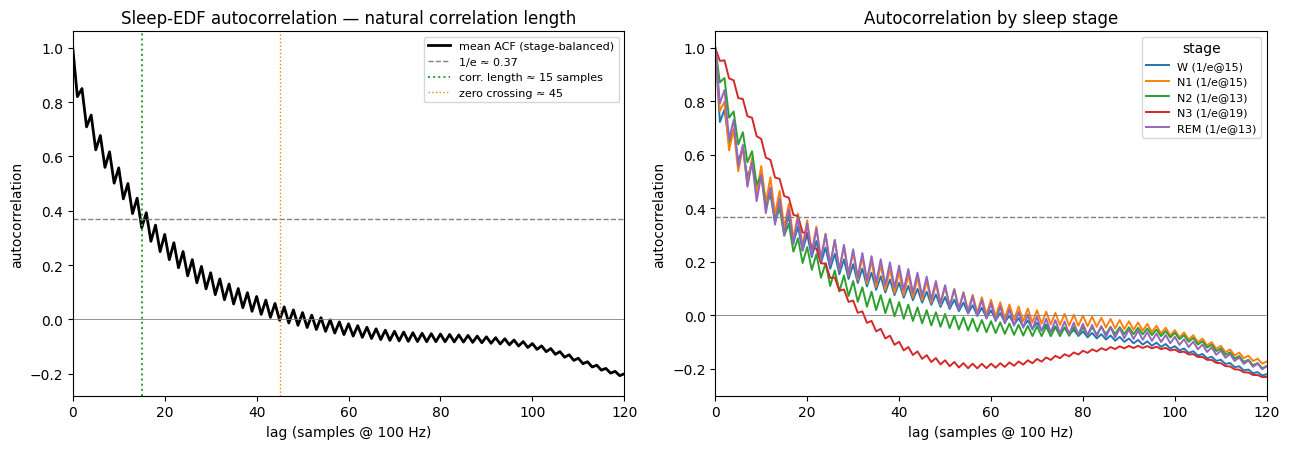

saved: results/sleep_edf/figures/sleep_edf_03_region_autocorrelation.png


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

# (a) overall ACF with the 1/e correlation length marked
ax[0].plot(lags, acf_all, color="k", lw=2, label="mean ACF (stage-balanced)")
ax[0].axhline(THR_E, color="grey", ls="--", lw=1, label="1/e ≈ 0.37")
ax[0].axhline(0.0, color="grey", lw=0.6)
ax[0].axvline(corr_len, color="C2", ls=":", lw=1.4, label=f"corr. length ≈ {corr_len} samples")
ax[0].axvline(zero_x, color="C1", ls=":", lw=1.0, label=f"zero crossing ≈ {zero_x}")
ax[0].set_xlim(0, 120); ax[0].set_xlabel("lag (samples @ 100 Hz)"); ax[0].set_ylabel("autocorrelation")
ax[0].set_title("Sleep-EDF autocorrelation — natural correlation length")
ax[0].legend(fontsize=8)

# (b) per-class ACF
class_cl = {}
for c in range(5):
    a = mean_acf(per_class[c])
    class_cl[c] = (first_below(a, THR_E), first_below(a, 0.0))
    ax[1].plot(lags, a, lw=1.4, label=f"{CLASS_NAMES[c]} (1/e@{class_cl[c][0]})")
ax[1].axhline(THR_E, color="grey", ls="--", lw=1)
ax[1].axhline(0.0, color="grey", lw=0.6)
ax[1].set_xlim(0, 120); ax[1].set_xlabel("lag (samples @ 100 Hz)"); ax[1].set_ylabel("autocorrelation")
ax[1].set_title("Autocorrelation by sleep stage")
ax[1].legend(fontsize=8, title="stage")

fig.tight_layout()
fig.savefig(FIG_DIR / "sleep_edf_03_region_autocorrelation.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved:", (FIG_DIR / 'sleep_edf_03_region_autocorrelation.png').relative_to(PROJECT_ROOT))


## 4. Class-dependence check

Sleep stages differ in rhythm, so we check whether the correlation length differs substantially by
stage — if it does, a single global region size is a simplification we should quantify.


In [6]:
print(f"{'stage':<6}{'1/e (samples)':>14}{'1/e (ms)':>10}{'1/e (%)':>9}{'zero-x':>9}{'~dom. freq':>12}")
print("-" * 60)
rows = []
for c in range(5):
    cl, zx = class_cl[c]
    fdom = FS / (4 * zx) if zx else float("nan")
    rows.append((CLASS_NAMES[c], cl, zx))
    print(f"{CLASS_NAMES[c]:<6}{cl:>14}{cl*1000/FS:>10.0f}{100*cl/N:>9.2f}{zx:>9}{fdom:>10.1f} Hz")

cls = [r[1] for r in rows]
print("-" * 60)
print(f"overall (stage-balanced): 1/e = {corr_len} samples ({100*corr_len/N:.2f}%), zero = {zero_x}")
print(f"per-class 1/e spread: {min(cls)}-{max(cls)} samples "
      f"(ratio {max(cls)/min(cls):.2f}x); std = {np.std(cls):.1f} samples")


stage  1/e (samples)  1/e (ms)  1/e (%)   zero-x  ~dom. freq
------------------------------------------------------------
W                 15       150     0.50       57       0.4 Hz
N1                15       150     0.50       61       0.4 Hz
N2                13       130     0.43       39       0.6 Hz
N3                19       190     0.63       33       0.8 Hz
REM               13       130     0.43       57       0.4 Hz
------------------------------------------------------------
overall (stage-balanced): 1/e = 15 samples (0.50%), zero = 45
per-class 1/e spread: 13-19 samples (ratio 1.46x); std = 2.2 samples


**Reading the class check.** The 1/e correlation length is remarkably stable across stages —
roughly **13–19 samples (130–190 ms)**, only a ~1.5× spread (std ≈ 2 samples). As expected
physiologically, **N3
(slow-wave sleep) has the longest** correlation length (its low-frequency slow waves stay coherent
longest), and its zero crossing sits near a **~0.75 Hz** slow-oscillation — the textbook slow-wave
frequency, a reassuring sanity check. Faster stages (N2, REM) are slightly shorter.

**Implication.** Because the spread is small (~1.4×, ~±2–3 samples), **a single global region size is
only a mild simplification** — no stage's grain is more than a few samples away from the pooled value.
It is worth noting the direction (N3 is the coarsest-grained stage) so that, if per-stage faithfulness
later looks unusual for N3, we remember its region contains marginally *fewer* correlation lengths than
other stages'. But there is no case here for stage-specific region sizes.


## 5. Comparing the measured scale to the 60-sample region size

The region size is fixed from sleep physiology at **60 samples (600 ms, 2% of the epoch → 50 regions)**,
approximately one spindle / K-complex / slow-wave event. The autocorrelation gives an independent check:

| Scale | Sleep-EDF (3000-sample epoch) | As % of epoch |
|-------|------------------------------|---------------|
| 1/e correlation length (measured) | ≈15 samples (150 ms) | 0.50 % |
| First zero crossing (measured) | ≈45 samples (450 ms) | 1.5 % |
| **Region size (physiological choice)** | **60 samples (600 ms)** | **2 %** |
| EEG event scale (spindles / K-complexes / slow waves) | ~50–150 samples | ~1.7–5 % |

**What the check says.** The measured correlation length (~15 samples) sits **well below** the 60-sample
region, and even the first zero crossing (~45 samples) is below it. So a 60-sample region comfortably
contains the signal's correlated structure — it never slices *inside* a coherent grain (that would need a
region under ~15 samples). At the same time 60 samples lands on the **EEG event scale** (~50–150 samples),
so each region is about the size of the waveform structure that actually defines a sleep stage. The
autocorrelation therefore **confirms** the physiological choice: 60 samples is comfortably above the
correlation-length floor and on the feature scale.

## 6. Conclusion

The region size is **60 samples (600 ms, 2% of the epoch → 50 regions)**, chosen from the temporal scale
of the waveform events that define sleep stages (spindles ~0.5–1.5 s, K-complexes ~0.5 s, slow waves ~1 s
≈ 50–150 samples at 100 Hz): one region ≈ one such event. 3000 ÷ 60 = 50 regions exactly.

**The autocorrelation confirms it.** Sleep-EDF's measured correlation length is ~15 samples (150 ms),
stable across stages (13–19 samples; N3 marginally coarsest, consistent with slow-wave sleep). Because
60 samples is ~4× this correlation length, a region always contains at least one coherent grain — it is
comfortably above the floor below which regions would fragment the signal — while sitting on the
physiologically meaningful event scale. Corroborating context: Khalili & Mohammadzadeh Asl (2021), on the
same task, use multi-scale CNN kernels spanning ~25–200 samples on the reasoning that stage-distinguishing
structure lives at that scale; 60 samples sits inside this range (supporting context, not validation).

**A single grid is used — there is no fine grid.** An earlier draft carried a second 30-sample grid; it
was dropped because it had no independent physiological or ML justification for that specific size.

*Nothing is wired in here — the region size lives in `src/config/sleep_edf.py`.*